In [2]:
import numpy as np
import numpy.ma as ma
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

Start with the designed switcher

In [58]:
res = np.arange(-16,16.01,0.1).round(2)
xlb = -12
xub = 2
ylb = -11
yub = 3
xlb_idx = np.where(res==xlb)[0][0]
xub_idx = np.where(res==xub)[0][0]
ylb_idx = np.where(res==ylb)[0][0]
yub_idx = np.where(res==yub)[0][0]
resx = res[xlb_idx:xub_idx]
resy = res[ylb_idx:yub_idx]

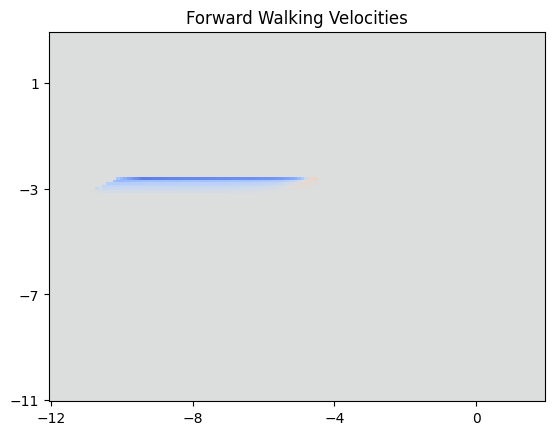

In [59]:
velocities_fw = np.loadtxt('./Forward Walkers/20/vel.dat').reshape((len(res),len(res))).swapaxes(0,1)
plt.pcolormesh(resx,resy,velocities_fw[ylb_idx:yub_idx,xlb_idx:xub_idx],cmap='coolwarm_r',vmin=-.627,vmax=.627)
plt.title('Forward Walking Velocities')
plt.xticks(resx.round(2)[::40])
plt.yticks(resy.round(2)[::40])
plt.show()

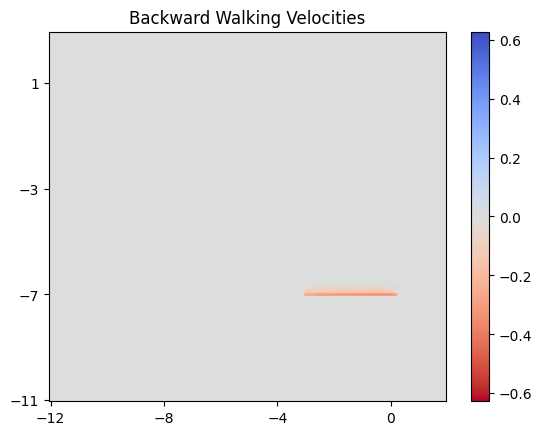

In [64]:
velocities_bw = np.loadtxt('./Backward Walkers/26/vel.dat').reshape((len(res),len(res))).swapaxes(0,1)
plt.pcolormesh(resx,resy,velocities_bw[ylb_idx:yub_idx,xlb_idx:xub_idx],cmap='coolwarm_r',vmin=-.627,vmax=.627)
plt.title('Backward Walking Velocities')
plt.xticks(resx.round(2)[::40])
plt.yticks(resy.round(2)[::40])
plt.colorbar()
plt.show()

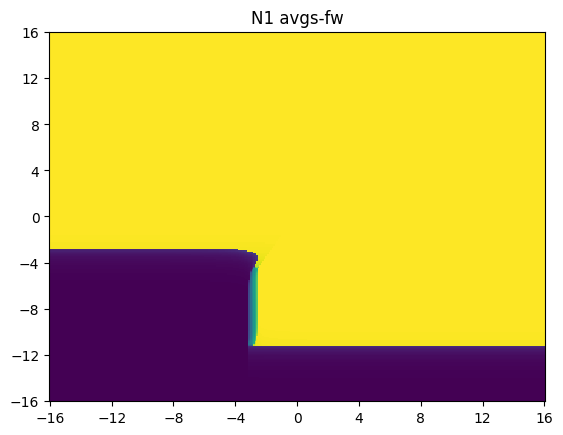

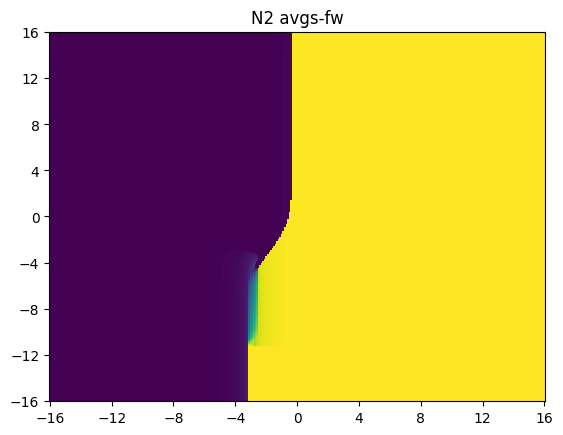

In [19]:
avgs = np.loadtxt('./Forward Walkers/20/avgs.dat').reshape((len(res),len(res),2))
avgs[:,:,0] = ma.masked_where(velocities_fw<0,avgs[:,:,0])
avgs[:,:,1] = ma.masked_where(velocities_fw<0,avgs[:,:,1])
plt.pcolormesh(res,res,avgs[:,:,0],vmin=0,vmax=1)
plt.title('N1 avgs-fw')
plt.xticks(res.round(2)[::40])
plt.yticks(res.round(2)[::40])
plt.show()
plt.pcolormesh(res,res,avgs[:,:,1],vmin=0,vmax=1)
plt.title('N2 avgs-fw')
plt.xticks(res.round(2)[::40])
plt.yticks(res.round(2)[::40])
plt.show()

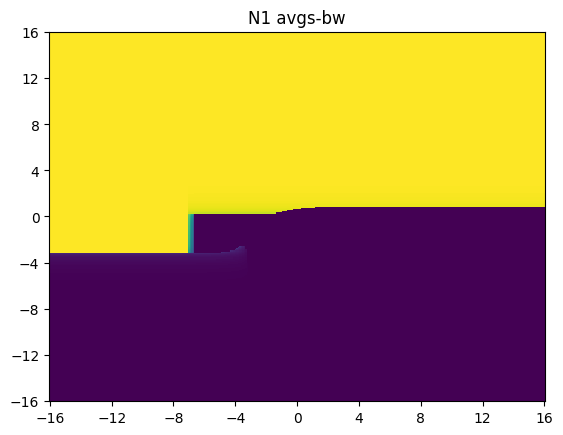

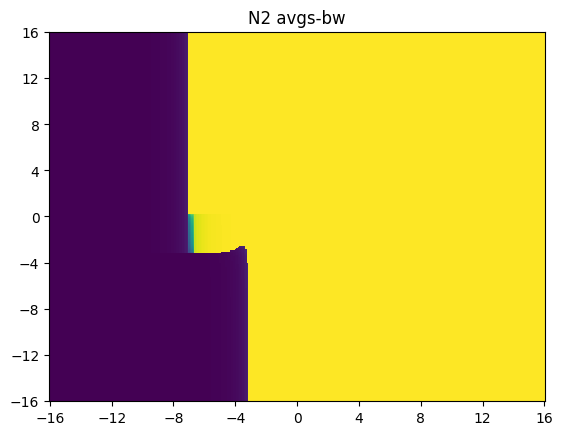

In [20]:
avgs = np.loadtxt('./Backward Walkers/26/avgs.dat').reshape((len(res),len(res),2))
avgs[:,:,0] = ma.masked_where(velocities_bw>0,avgs[:,:,0],copy=False)
avgs[:,:,1] = ma.masked_where(velocities_bw<0,avgs[:,:,1],copy=False)
plt.pcolormesh(res,res,avgs[:,:,0],vmin=0,vmax=1)
plt.title('N1 avgs-bw')
plt.xticks(res.round(2)[::40])
plt.yticks(res.round(2)[::40])
plt.show()
plt.pcolormesh(res,res,avgs[:,:,1],vmin=0,vmax=1)
plt.title('N2 avgs-bw')
plt.xticks(res.round(2)[::40])
plt.yticks(res.round(2)[::40])
plt.show()

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

def imshow3d(ax, array, x=None, y=None, value_direction='z', pos=0, norm=None, cmap=None):
    """
    Display a 2D array as a color-coded image embedded in 3D using real coordinates.

    Parameters
    ----------
    ax : Axes3D
    array : 2D numpy array
    x, y : 1D arrays
        Real coordinate axes corresponding to array columns and rows.
    value_direction : {'x','y','z'}
        Axis perpendicular to the image plane.
    pos : float
        Location of the plane along value_direction.
    """

    if norm is None:
        norm = Normalize()

    colors = plt.get_cmap(cmap)(norm(array))

    ny, nx = array.shape

    if x is None:
        x = np.arange(nx + 1)
    if y is None:
        y = np.arange(ny + 1)

    xi, yi = np.meshgrid(x, y)

    if value_direction == 'z':
        zi = np.full_like(xi, pos)

    elif value_direction == 'x':
        zi, yi = np.meshgrid(x, y)
        xi = np.full_like(yi, pos)

    elif value_direction == 'y':
        xi, zi = np.meshgrid(x, y)
        yi = np.full_like(xi, pos)

    else:
        raise ValueError(f"Invalid value_direction: {value_direction!r}")

    ax.plot_surface(xi, yi, zi, rstride=1, cstride=1, facecolors=colors, shade=False)



In [6]:
paramseries = np.loadtxt('./neuralparameters.dat')

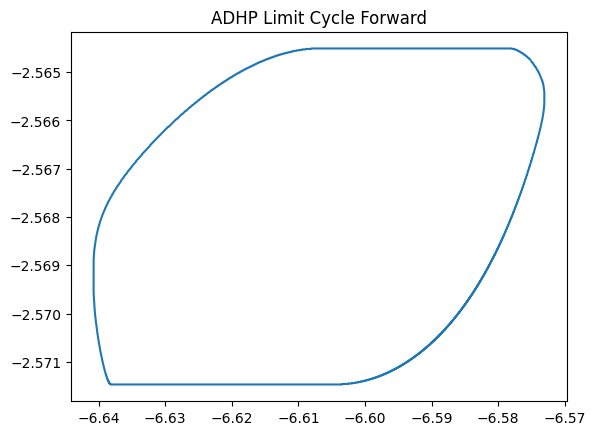

In [100]:
plt.title("ADHP Limit Cycle Forward")
plt.plot(paramseries[250470:255320,0],paramseries[250470:255320,1])
plt.show()

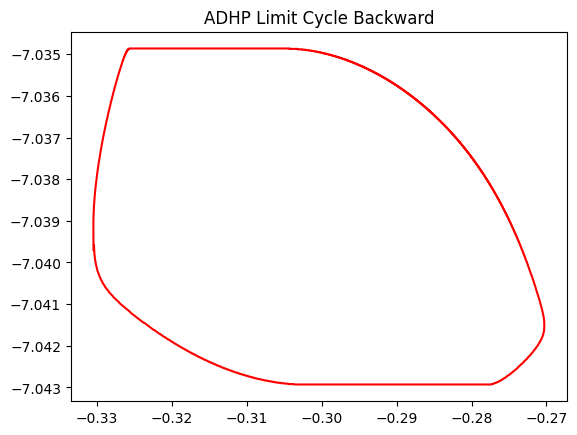

In [131]:
plt.title("ADHP Limit Cycle Backward")
plt.plot(paramseries[965000:969370,0],paramseries[965000:969370,1],color='r')
plt.show()

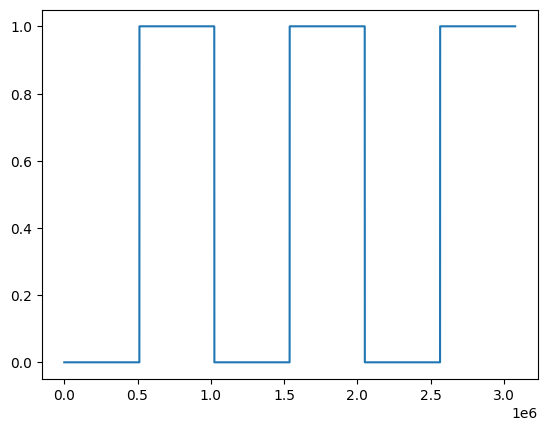

In [23]:
modulated = np.zeros_like(paramseries[:,0])
modulated[np.where(paramseries[:,0]>-4.5)[0]]=1
plt.plot(modulated)

In [24]:
# plt.plot(paramseries[:,0],paramseries[:,1])
new_paramseries = np.zeros((len(paramseries),3))
new_paramseries[:,:-1] = paramseries
new_paramseries[:,-1] = modulated*5

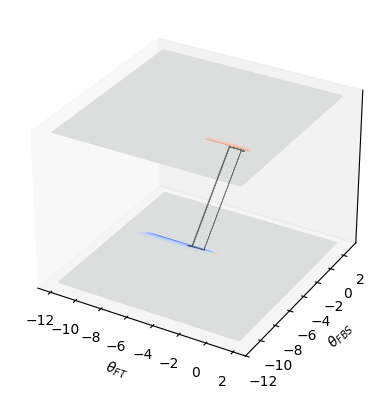

In [63]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.set(xlabel=r'$\theta_{FT}$', ylabel=r'$\theta_{FBS}$', zlabel='Modulation')
ax.set(zticks=[])
# ax.set(xticks=np.arange(-16,16.01,8),yticks=np.arange(-16,16.01,8),zticks=[])
# ax.set(xticklabels=np.arange(-16,16.01,8),yticklabels=np.arange(-16,16.01,8))
ax.grid(False)
# ax.set(xlim3d=[-8,8],ylim3d=[-12,4],zlim3d=[0,5])

norm = Normalize(vmin=-0.627,vmax=0.627)

imshow3d(ax,velocities_fw[ylb_idx:yub_idx,xlb_idx:xub_idx],x=resx,y=resy ,cmap='coolwarm_r',norm=norm)
imshow3d(ax,velocities_bw[ylb_idx:yub_idx,xlb_idx:xub_idx],x=resx,y=resy, cmap='coolwarm_r',norm=norm,pos=5)
ax.plot3D(new_paramseries[:,0],new_paramseries[:,1],new_paramseries[:,2],zorder=100,color='k',alpha=.5,linewidth=.5)

plt.show()

In [136]:
res = np.arange(-16,16.01,0.1).round(2)
xlb = -12
xub = 2
ylb = -13
yub = 1
xlb_idx = np.where(res==xlb)[0][0]
xub_idx = np.where(res==xub)[0][0]
ylb_idx = np.where(res==ylb)[0][0]
yub_idx = np.where(res==yub)[0][0]
resx = res[xlb_idx:xub_idx]
resy = res[ylb_idx:yub_idx]

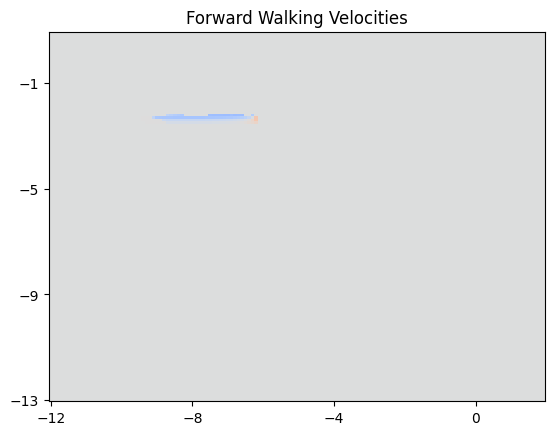

In [137]:
velocities_fw = np.loadtxt('./Evolutions_2N/8/extracted_fwvel.dat').reshape((len(res),len(res))).swapaxes(0,1)
plt.pcolormesh(resx,resy,velocities_fw[ylb_idx:yub_idx,xlb_idx:xub_idx],cmap='coolwarm_r',vmin=-.627,vmax=.627)
plt.title('Forward Walking Velocities')
plt.xticks(resx.round(2)[::40])
plt.yticks(resy.round(2)[::40])
plt.show()

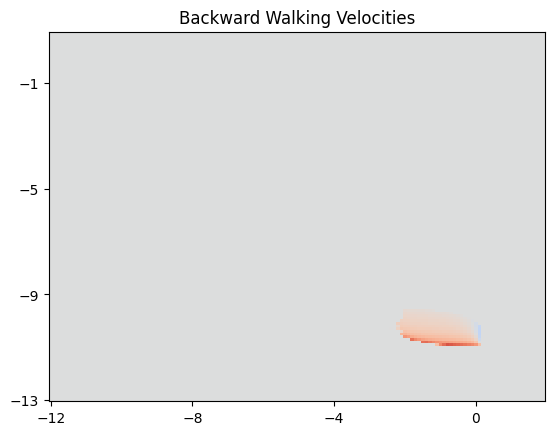

In [ ]:
velocities_bw = np.loadtxt('./Evolutions_2N/8/extracted_bwvel.dat').reshape((len(res),len(res))).swapaxes(0,1)
plt.pcolormesh(resx,resy,velocities_bw[ylb_idx:yub_idx,xlb_idx:xub_idx],cmap='coolwarm_r',vmin=-.627,vmax=.627)
plt.title('Backward Walking Velocities')
plt.xticks(resx.round(2)[::40])
plt.yticks(resy.round(2)[::40])
# plt.colorbar()
plt.show()

In [139]:
paramseries = np.loadtxt('./neuralparameters.dat')

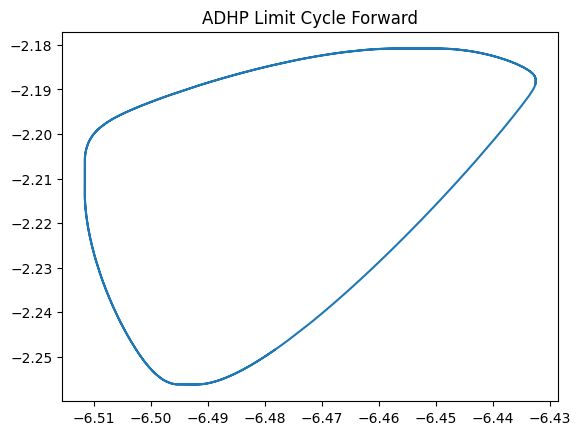

In [166]:
plt.title("ADHP Limit Cycle Forward")
plt.plot(paramseries[1500000:1510000,0],paramseries[1500000:1510000,1])
plt.show()

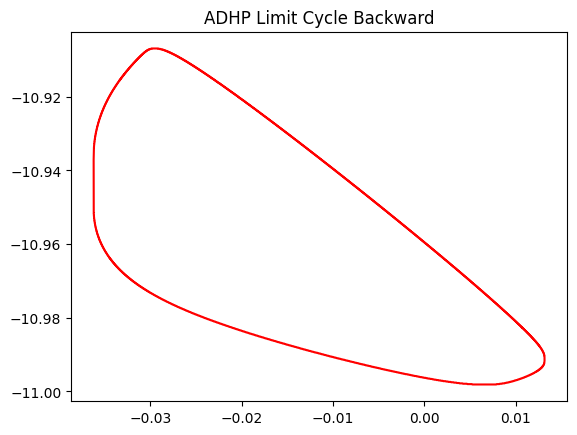

In [157]:
plt.title("ADHP Limit Cycle Backward")
plt.plot(paramseries[965000:969750,0],paramseries[965000:969750,1],color='r')
plt.show()

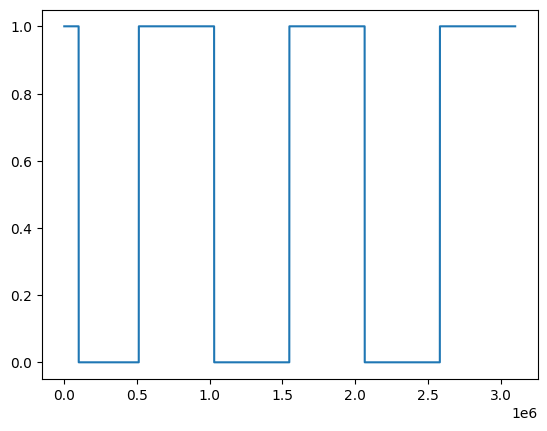

In [140]:
modulated = np.zeros_like(paramseries[:,0])
modulated[np.where(paramseries[:,0]>-4.5)[0]]=1
plt.plot(modulated)

In [141]:
# plt.plot(paramseries[:,0],paramseries[:,1])
new_paramseries = np.zeros((len(paramseries),3))
new_paramseries[:,:-1] = paramseries
new_paramseries[:,-1] = modulated*5

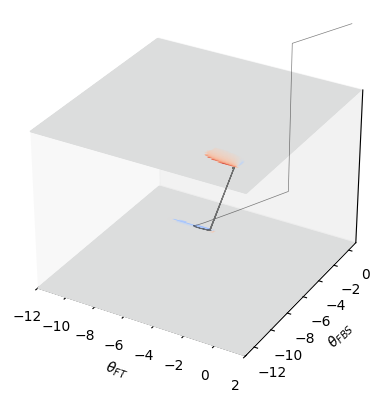

In [143]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.set(xlabel=r'$\theta_{FT}$', ylabel=r'$\theta_{FBS}$', zlabel='Modulation')
ax.set(zticks=[])
# ax.set(xticks=np.arange(-16,16.01,8),yticks=np.arange(-16,16.01,8),zticks=[])
# ax.set(xticklabels=np.arange(-16,16.01,8),yticklabels=np.arange(-16,16.01,8))
ax.grid(False)
ax.set(xlim3d=[xlb,xub],ylim3d=[ylb,yub],zlim3d=[0,5])

norm = Normalize(vmin=-0.627,vmax=0.627)

imshow3d(ax,velocities_fw[ylb_idx:yub_idx,xlb_idx:xub_idx],x=resx,y=resy ,cmap='coolwarm_r',norm=norm)
imshow3d(ax,velocities_bw[ylb_idx:yub_idx,xlb_idx:xub_idx],x=resx,y=resy, cmap='coolwarm_r',norm=norm,pos=5)
ax.plot3D(new_paramseries[:,0],new_paramseries[:,1],new_paramseries[:,2],zorder=100,color='k',alpha=.5,linewidth=.5)

plt.show()

In [147]:
print(np.max(new_paramseries[:,2]))

5.0
